# 0. Preparação dos dados

Somente uma das duas células de dados deve ser executada: a célula de dados sintéticos ou a célula de leitura do CSV. Ao final, a série escolhida deve estar armazenada na variável `serie`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Dados sintéticos

In [5]:
# serie = np.array([
#     0.18, 0.35, 0.42, 0.27, 0.61,
#     0.55, 0.74, 0.49, 0.83, 0.92,
#     1.05, 0.68, 1.12, 0.77, 1.25,
#     0.96, 1.34, 1.48, 1.16, 1.57,
#     1.72, 1.41, 1.88, 2.15, 2.32,
#     2.58, 2.91, 3.37, 4.08, 5.12
# ], dtype=float)

# nomeSerie = "Dados sintéticos"

# n = len(serie)

# print("Série selecionada:", nomeSerie)
# print("Quantidade de valores:", n)
# print("Mínimo:", serie.min())
# print("Máximo:", serie.max())
# print("Média:", serie.mean())

## Dados Reais

Colunas disponíveis:
['runId', 'scoreArtifactId', 'dataset', 'instanceId', 'trueLabel', 'labelName', 'isAttack', 'modelCode', 'modelConfig', 'modelName', 'normalizer', 'normalizerUpdatePolicy', 'trainingStrategy', 'warmup', 'isWarmup', 'runSeed', 'rawScore', 'scoreMa10', 'scoreMa50', 'scoreMa100', 'Max Packet Length', 'Average Packet Size', 'Fwd Packet Length Min', 'Min Packet Length', 'Fwd Packet Length Max', 'Packet Length Mean', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'min_seg_size_forward', 'ACK Flag Count', 'Flow Duration', 'Fwd IAT Total', 'Flow IAT Max', 'Fwd IAT Max', 'Flow IAT Std', 'Fwd IAT Std', 'Fwd IAT Mean', 'Flow IAT Mean', 'Total Length of Fwd Packets', 'Subflow Fwd Bytes', 'act_data_pkt_fwd', 'Subflow Fwd Packets', 'Total Fwd Packets', 'Down/Up Ratio', 'Init_Win_bytes_backward', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Flow IAT Min', 'Bwd Packet Length Max', 'URG Flag Count', 'Bwd IAT Total', 'Bwd Packets/s', 'Init_Win_bytes_forward', 'trainingFee

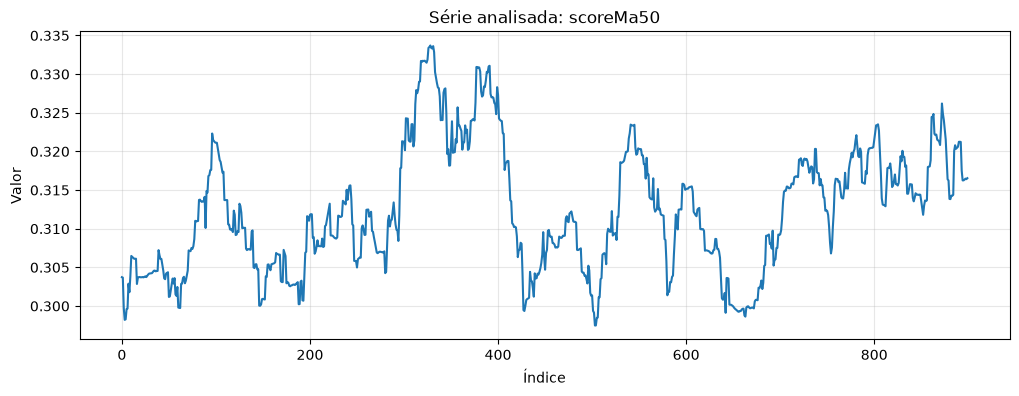

In [6]:
caminhoCSV = "data/AIF_scores.csv"
# caminhoCSV = "data/BENIGN.csv"
dados = pd.read_csv(caminhoCSV)
# dadosSelecionados = dados.copy()
dadosSelecionados = dados.iloc[1100:2000].copy()

print("Colunas disponíveis:")
print(dadosSelecionados.columns.tolist())

# Altere somente o nome da coluna.
colunaSelecionada = "scoreMa50"
# colunaSelecionada = "score_media_10"

serie = (pd.to_numeric(dadosSelecionados[colunaSelecionada], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .to_numpy(dtype=float)
)

nomeSerie = colunaSelecionada
n = len(serie)

print("Coluna selecionada:", nomeSerie)
print("Quantidade de valores:", n)
print("Mínimo:", serie.min())
print("Máximo:", serie.max())
print("Média:", serie.mean())

plt.figure(figsize=(12, 4))
plt.plot(serie)
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title(f"Série analisada: {nomeSerie}")
plt.grid(alpha=0.3)
plt.show()

# 1. Seleção da cauda e cálculo dos excessos

A GPD não é aplicada a todos os valores da série. Ela é utilizada somente para modelar a região extrema, formada pelos valores que ultrapassam um limiar intermediário.

Nesta etapa escolhemos esse limiar, identificamos os picos localizados acima dele e calculamos os excessos. O excesso representa apenas quanto cada pico ultrapassou o início da cauda. Esses excessos serão os dados utilizados pela GPD nas próximas etapas.

<img src="img/GPD_01.png" width="900">

## 1.1 Escolha do limiar intermediário

O limiar intermediário indica onde começa a região extrema da série. Ele ainda não é utilizado para decidir se um valor é uma anomalia. Sua função é somente selecionar os valores que serão utilizados para aprender o comportamento da cauda.

O limiar será calculado por meio de um quantil alto da própria série. Dessa forma, quando outra coluna do CSV for selecionada, o valor do limiar será automaticamente adaptado à distribuição daquela coluna.

In [7]:
# Quantil usado para definir o início da cauda.
quantilInicial = 0.98

limiarT = float(np.quantile(serie, quantilInicial))

print("Quantil utilizado:", quantilInicial)
print("Limiar intermediário t:", limiarT)

Quantil utilizado: 0.98
Limiar intermediário t: 0.33089106383559685


## 1.2 Identificação dos picos e cálculo dos excessos

Os valores acima do limiar intermediário são considerados picos. Entretanto, a GPD não utiliza diretamente o valor absoluto desses picos. Para cada pico, calculamos apenas a distância entre ele e o limiar.

Essa distância recebe o nome de excesso. O conjunto de excessos representa o comportamento da cauda que será analisado pela GPD.

In [8]:
mascaraPicos = serie > limiarT
picos = serie[mascaraPicos]
excessos = picos - limiarT
numeroPicos = len(excessos)

print("Quantidade total de valores n:", n)
print("Quantidade de picos Nt:", numeroPicos)
print("Picos:", picos)
print("Excessos:", excessos)

indices = np.arange(len(serie))
excessosCompletos = np.where(mascaraPicos, serie - limiarT, np.nan)

tabelaCauda = pd.DataFrame({
    "indice": indices,
    "valor": serie,
    "acimaDeT": mascaraPicos,
    "excesso": excessosCompletos
})

tabelaCauda

Quantidade total de valores n: 900
Quantidade de picos Nt: 18
Picos: [0.33170376 0.33157303 0.33172786 0.33168106 0.33173817 0.3316053
 0.3314769  0.33188172 0.33339449 0.33351457 0.33370285 0.33338091
 0.33331234 0.33362216 0.33284819 0.33092847 0.33099018 0.33107765]
Excessos: [8.12693842e-04 6.81969287e-04 8.36800779e-04 7.90000627e-04
 8.47108113e-04 7.14232711e-04 5.85838654e-04 9.90654365e-04
 2.50342374e-03 2.62350301e-03 2.81178868e-03 2.48984120e-03
 2.42128096e-03 2.73110046e-03 1.95712478e-03 3.74075169e-05
 9.91184728e-05 1.86585902e-04]


,indice,valor,acimaDeT,excesso
0,0,0.303731,False,NaN
1,1,0.303673,False,NaN
2,2,0.299726,False,NaN
3,3,0.298208,False,NaN
4,4,0.298279,False,NaN
...,...,...,...,...
895,895,0.316256,False,NaN
896,896,0.316347,False,NaN
897,897,0.316479,False,NaN
898,898,0.316411,False,NaN


## 1.3 Visualização da cauda selecionada

O gráfico permite observar quais valores foram selecionados para a modelagem da cauda. Os pontos destacados acima da linha horizontal são os picos utilizados para calcular os excessos.

É importante perceber que esses picos ainda não são necessariamente anomalias. Eles representam apenas valores extremos utilizados para aprender o comportamento da cauda.

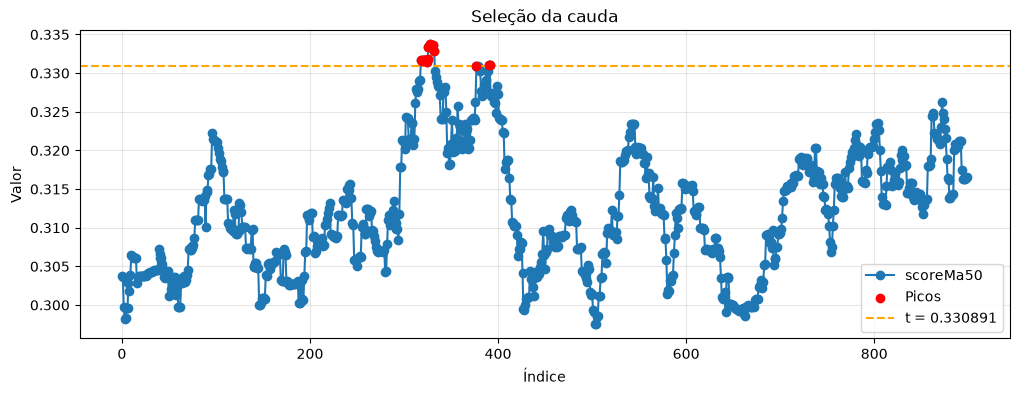

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(indices, serie, marker="o", label=nomeSerie)
plt.scatter(indices[mascaraPicos], serie[mascaraPicos], label="Picos", color="red", zorder=5)
plt.axhline(limiarT, linestyle="--", label=f"t = {limiarT:.6f}", color="orange")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title("Seleção da cauda")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Função de distribuição acumulada da GPD

Nesta etapa começamos a utilizar a GPD para descrever os excessos encontrados anteriormente. A função de distribuição acumulada indica a posição de cada excesso dentro da distribuição.

Valores menores possuem uma probabilidade acumulada menor. Conforme o excesso aumenta, a probabilidade acumulada se aproxima do total da distribuição. Inicialmente, utilizaremos parâmetros definidos manualmente apenas para compreender o comportamento da função.

<img src="img/GPD_02.png" width="900">

## 2.1 Parâmetros utilizados inicialmente

A GPD possui um parâmetro de forma e um parâmetro de escala. O parâmetro de forma controla o comportamento da cauda, enquanto o parâmetro de escala controla a dispersão dos excessos.

Nesta primeira análise, esses valores serão escolhidos manualmente. Eles ainda não representam os melhores parâmetros para os dados. A estimação será realizada posteriormente pela log-verossimilhança.

In [10]:
gammaManual = 0.20
sigmaManual = float(np.mean(excessos))

if sigmaManual <= 0:
    raise ValueError("Sigma deve ser maior que zero.")

print("Gamma manual:", gammaManual)
print("Sigma manual:", sigmaManual)

Gamma manual: 0.2
Sigma manual: 0.0013400262824344897


## 2.2 Implementação da distribuição acumulada

A função abaixo recebe os excessos e os parâmetros escolhidos. Ela calcula a probabilidade acumulada correspondente a cada valor.

O caso em que o parâmetro de forma está próximo de zero é tratado separadamente, pois a GPD assume nesse ponto um comportamento exponencial.

In [11]:
def cdfGPD(valores, gamma, sigma):
    valores = np.asarray(valores, dtype=float)

    if sigma <= 0:
        raise ValueError("Sigma deve ser maior que zero.")

    if np.any(valores < 0):
        raise ValueError("Os excessos devem ser não negativos.")

    if np.isclose(gamma, 0.0):
        return 1 - np.exp(-valores / sigma)

    suporte = 1 + gamma * valores / sigma
    resultado = np.full(valores.shape, np.nan, dtype=float)
    validos = suporte > 0
    resultado[validos] = (1 - suporte[validos] ** (-1 / gamma))

    return resultado

In [12]:
cdfManual = cdfGPD(excessos, gammaManual, sigmaManual)

tabelaCDF = pd.DataFrame({
    "pico": picos,
    "excesso": excessos,
    "probabilidadeAcumulada": cdfManual
})

tabelaCDF

,pico,excesso,probabilidadeAcumulada
0,0.331704,0.000813,0.435843
1,0.331573,0.000682,0.384091
2,0.331728,0.000837,0.444808
3,0.331681,0.000790,0.427245
4,0.331738,0.000847,0.448588
5,0.331605,0.000714,0.397375
6,0.331477,0.000586,0.342373
7,0.331882,0.000991,0.498163
8,0.333394,0.002503,0.795526
9,0.333515,0.002624,0.808358


## 2.3 Interpretação da probabilidade acumulada

A probabilidade acumulada mostra quanto da distribuição está localizado abaixo ou até determinado excesso. Um excesso com probabilidade acumulada elevada encontra-se mais distante na cauda do que outro com probabilidade menor.

Como os parâmetros ainda foram definidos manualmente, os valores desta etapa servem apenas para compreender a função. Posteriormente, o mesmo cálculo será repetido com os parâmetros estimados a partir dos próprios excessos.

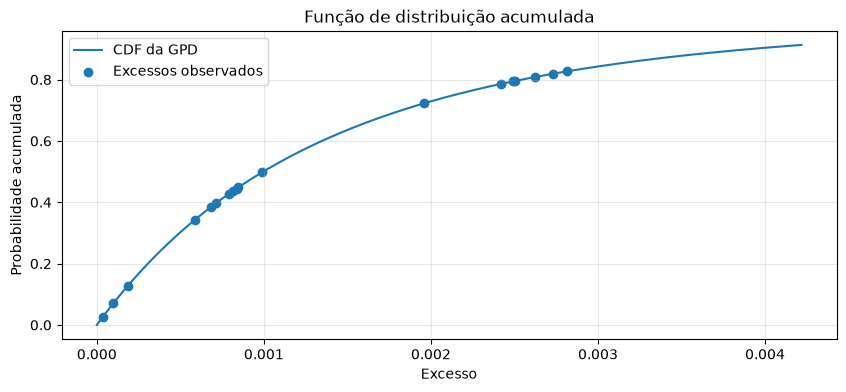

In [13]:
eixoExcessos = np.linspace(0, excessos.max() * 1.5, 400)
curvaCDF = cdfGPD(eixoExcessos, gammaManual, sigmaManual)

plt.figure(figsize=(10, 4))
plt.plot(eixoExcessos, curvaCDF, label="CDF da GPD")
plt.scatter(excessos, cdfManual, label="Excessos observados")
plt.xlabel("Excesso")
plt.ylabel("Probabilidade acumulada")
plt.title("Função de distribuição acumulada")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Função de sobrevivência e densidade

Nesta etapa analisamos duas funções complementares da GPD. A função de sobrevivência informa a probabilidade de encontrar um excesso maior que o valor observado. Essa interpretação será importante para o cálculo do limiar extremo.

A função de densidade indica quais regiões da cauda são mais compatíveis com os parâmetros escolhidos. Posteriormente, ela será utilizada pela log-verossimilhança para avaliar quais parâmetros explicam melhor os excessos observados.

<img src="img/GPD_03.png" width="900">

In [14]:
def sobrevivenciaGPD(valores, gamma, sigma):
    return 1 - cdfGPD(valores, gamma, sigma)

def densidadeGPD(valores, gamma, sigma):
    valores = np.asarray(valores, dtype=float)

    if sigma <= 0:
        raise ValueError("Sigma deve ser maior que zero.")

    if np.any(valores < 0):
        raise ValueError("Os excessos devem ser não negativos.")

    if np.isclose(gamma, 0.0):
        return (np.exp(-valores / sigma) / sigma)

    suporte = 1 + gamma * valores / sigma
    resultado = np.full(valores.shape, np.nan, dtype=float)
    validos = suporte > 0
    resultado[validos] = ((1 / sigma) * suporte[validos] ** (-1 / gamma - 1))

    return resultado

In [15]:
sobrevivenciaManual = sobrevivenciaGPD(excessos, gammaManual, sigmaManual)
densidadeManual = densidadeGPD(excessos, gammaManual, sigmaManual)

tabelaFuncoes = pd.DataFrame({
    "pico": picos,
    "excesso": excessos,
    "cdf": cdfManual,
    "sobrevivencia": sobrevivenciaManual,
    "densidade": densidadeManual
})

tabelaFuncoes

,pico,excesso,cdf,sobrevivencia,densidade
0,0.331704,0.000813,0.435843,0.564157,375.462773
1,0.331573,0.000682,0.384091,0.615909,417.163995
2,0.331728,0.000837,0.444808,0.555192,368.314622
3,0.331681,0.000790,0.427245,0.572755,382.340027
4,0.331738,0.000847,0.448588,0.551412,365.306844
5,0.331605,0.000714,0.397375,0.602625,406.390123
6,0.331477,0.000586,0.342373,0.657627,451.296860
7,0.331882,0.000991,0.498163,0.501837,326.258865
8,0.333394,0.002503,0.795526,0.204474,111.084354
9,0.333515,0.002624,0.808358,0.191642,102.772090


## 3.1 Interpretação das funções

A função de sobrevivência diminui conforme o excesso aumenta, pois valores maiores são menos prováveis dentro da cauda. Ela responde diretamente à pergunta de qual é a probabilidade de aparecer um excesso ainda maior.

A densidade mostra onde os valores estão mais concentrados segundo os parâmetros atuais. Valores com baixa densidade são menos compatíveis com o comportamento estimado para a cauda.

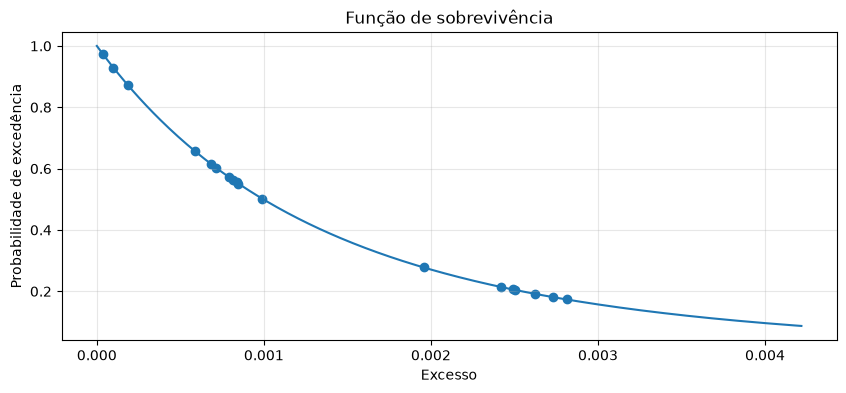

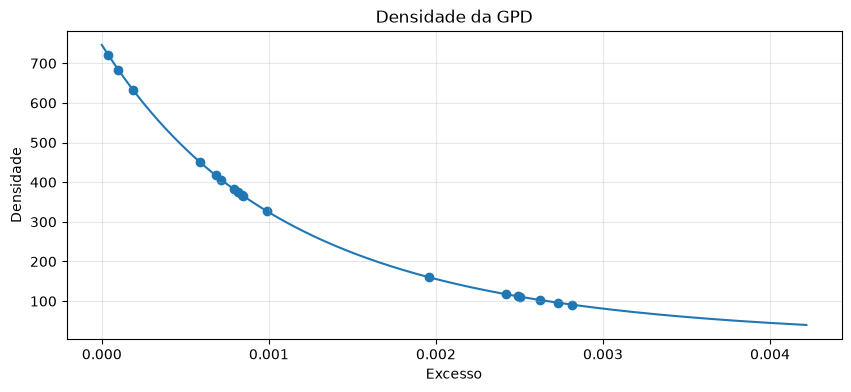

In [16]:
curvaSobrevivencia = sobrevivenciaGPD(eixoExcessos, gammaManual, sigmaManual)
plt.figure(figsize=(10, 4))
plt.plot(eixoExcessos, curvaSobrevivencia)
plt.scatter(excessos, sobrevivenciaManual)
plt.xlabel("Excesso")
plt.ylabel("Probabilidade de excedência")
plt.title("Função de sobrevivência")
plt.grid(alpha=0.3)
plt.show()

curvaDensidade = densidadeGPD(eixoExcessos, gammaManual, sigmaManual)
plt.figure(figsize=(10, 4))
plt.plot(eixoExcessos, curvaDensidade)
plt.scatter(excessos, densidadeManual)
plt.xlabel("Excesso")
plt.ylabel("Densidade")
plt.title("Densidade da GPD")
plt.grid(alpha=0.3)
plt.show()

## 3.2 Influência do parâmetro de forma

Nesta comparação alteramos apenas o parâmetro de forma, mantendo a escala fixa. Dessa maneira, podemos observar como a cauda muda entre comportamentos limitados, exponenciais e pesados.

Uma curva que diminui lentamente indica que a distribuição atribui maior probabilidade a excessos muito elevados.

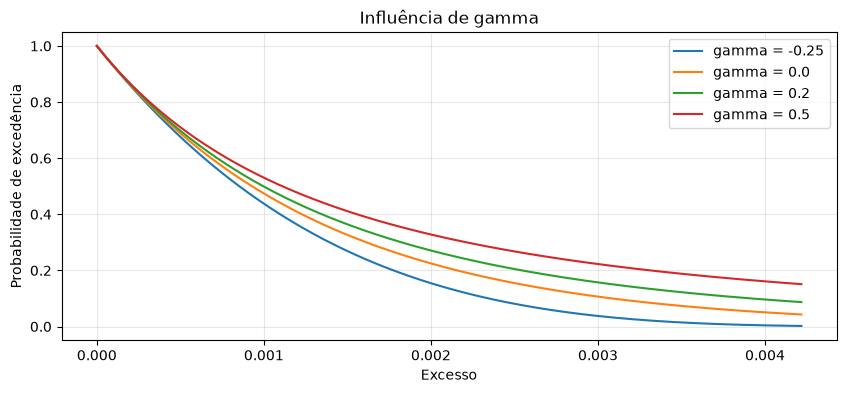

In [17]:
valoresGamma = [-0.25, 0.0, 0.20, 0.50]

plt.figure(figsize=(10, 4))
for gammaAtual in valoresGamma:
    curvaAtual = sobrevivenciaGPD(eixoExcessos, gammaAtual, sigmaManual)
    plt.plot(eixoExcessos, curvaAtual, label=f"gamma = {gammaAtual}")

plt.xlabel("Excesso")
plt.ylabel("Probabilidade de excedência")
plt.title("Influência de gamma")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3.3 Influência do parâmetro de escala

Nesta comparação mantemos o parâmetro de forma fixo e alteramos somente a escala. Uma escala maior torna a cauda mais espalhada e aumenta a probabilidade atribuída a excessos elevados.

Essa diferença será importante ao comparar o score bruto com as médias móveis, pois cada representação pode produzir excessos em escalas diferentes.

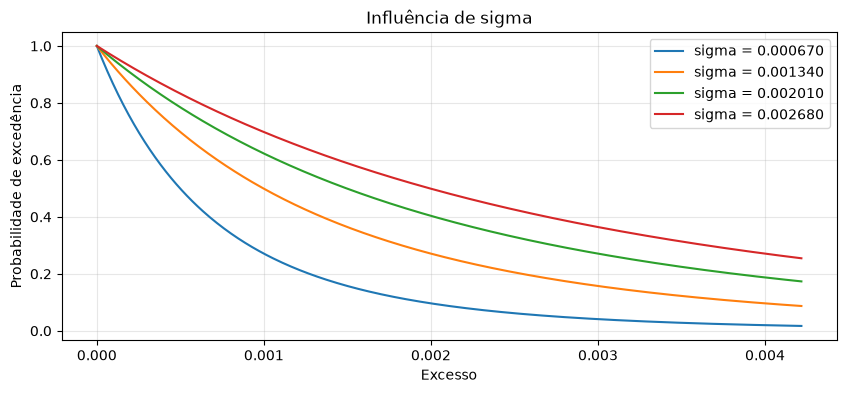

In [18]:
valoresSigma = [sigmaManual * 0.50, sigmaManual, sigmaManual * 1.50, sigmaManual * 2.00]

plt.figure(figsize=(10, 4))
for sigmaAtual in valoresSigma:
    curvaAtual = sobrevivenciaGPD(eixoExcessos, gammaManual, sigmaAtual)
    plt.plot(eixoExcessos, curvaAtual, label=f"sigma = {sigmaAtual:.6f}")

plt.xlabel("Excesso")
plt.ylabel("Probabilidade de excedência")
plt.title("Influência de sigma")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Log-verossimilhança e estimação dos parâmetros

Até esta etapa, os parâmetros da GPD foram definidos manualmente apenas para observar o comportamento de suas funções. Agora utilizaremos os excessos selecionados anteriormente para estimar quais valores de forma e escala representam melhor a cauda observada.

A qualidade de cada combinação será avaliada pela log-verossimilhança. Quanto maior seu valor, maior é a compatibilidade entre os parâmetros e os excessos. Primeiro será utilizada uma busca em grade, que facilita a visualização do processo. Depois será aplicada a técnica de Grimshaw, utilizada pelo SPOT e pelo DSPOT para realizar essa estimação de maneira mais apropriada.

<img src="img/GPD_04.png" width="900">

In [19]:
def logVerossimilhancaGPD(valores, gamma, sigma):
    valores = np.asarray(valores, dtype=float)
    quantidade = len(valores)

    if quantidade == 0:
        return -np.inf

    if sigma <= 0:
        return -np.inf

    if np.any(valores < 0):
        return -np.inf

    if np.isclose(gamma, 0.0):
        return (-quantidade * np.log(sigma) - np.sum(valores) / sigma)

    suporte = 1 + gamma * valores / sigma

    if np.any(suporte <= 0):
        return -np.inf

    return (-quantidade * np.log(sigma) - (1 + 1 / gamma) * np.sum(np.log(suporte)))

logManual = logVerossimilhancaGPD(excessos, gammaManual, sigmaManual)

print("Log-verossimilhança dos parâmetros manuais:", logManual)

Log-verossimilhança dos parâmetros manuais: 100.16333235280047


## 4.1 Estimação dos parâmetros por busca em grade

A busca em grade testa várias combinações previamente definidas para os parâmetros de forma e escala. Para cada combinação, calculamos a log-verossimilhança dos mesmos excessos e armazenamos apenas os resultados matematicamente válidos.

Ao final, as combinações são ordenadas da maior para a menor log-verossimilhança. A primeira linha representa a melhor solução encontrada dentro da grade testada. Esse resultado é uma aproximação, pois os parâmetros ficam limitados aos valores discretos presentes nos intervalos escolhidos.

In [20]:
# Escala de referência calculada a partir dos excessos observados.
mediaExcessos = float(np.mean(excessos))
desvioExcessos = (float(np.std(excessos, ddof=1))
    if len(excessos) > 1
    else mediaExcessos
)

escalaReferencia = max(mediaExcessos, desvioExcessos, 1e-8)

# Valores candidatos para o parâmetro de forma.
gradeGamma = np.linspace(-0.40, 0.80, 121)

# Valores candidatos para o parâmetro de escala.
gradeSigma = np.linspace(escalaReferencia * 0.10, escalaReferencia * 3.00, 150)

print("Média dos excessos:", mediaExcessos)
print("Desvio dos excessos:", desvioExcessos)
print("Valores de gamma testados:", len(gradeGamma))
print("Valores de sigma testados:", len(gradeSigma))
print("Total de combinações:", len(gradeGamma) * len(gradeSigma))

Média dos excessos: 0.0013400262824344897
Desvio dos excessos: 0.0010039157289681514
Valores de gamma testados: 121
Valores de sigma testados: 150
Total de combinações: 18150


### 4.1.1 Avaliação das combinações

Nesta etapa, todas as combinações da grade são avaliadas. Algumas delas podem ser descartadas porque produzem uma escala inválida ou violam a região permitida pela GPD.

A tabela resultante apresenta primeiro as combinações que melhor explicam os excessos. A diferença entre as primeiras linhas também ajuda a verificar se existe uma região bem definida de bons parâmetros ou se várias combinações produzem resultados muito próximos.

In [21]:
resultadosGrade = []

for gammaAtual in gradeGamma:
    for sigmaAtual in gradeSigma:
        logAtual = logVerossimilhancaGPD(excessos, gammaAtual, sigmaAtual)

        if np.isfinite(logAtual):
            resultadosGrade.append({
                "gamma": gammaAtual,
                "sigma": sigmaAtual,
                "logVerossimilhanca": logAtual
            })

if len(resultadosGrade) == 0:
    raise RuntimeError("Nenhuma combinação válida foi encontrada na grade.")

tabelaGrade = pd.DataFrame(resultadosGrade)

tabelaGradeOrdenada = (tabelaGrade
    .sort_values("logVerossimilhanca", ascending=False)
    .reset_index(drop=True)
)

tabelaGradeOrdenada.head(10)

,gamma,sigma,logVerossimilhanca
0,-0.40,0.001725,102.769746
1,-0.40,0.001699,102.767713
2,-0.40,0.001751,102.762447
3,-0.40,0.001673,102.755313
4,-0.40,0.001777,102.746728
5,-0.40,0.001647,102.731366
6,-0.39,0.001699,102.726730
7,-0.39,0.001725,102.724396
8,-0.40,0.001803,102.723395
9,-0.39,0.001673,102.719329


### 4.1.2 Melhor resultado da busca em grade

A melhor combinação é retirada da primeira linha da tabela ordenada. Esses parâmetros serão armazenados separadamente para que possam ser comparados com os valores obtidos pelo Grimshaw.

O valor da log-verossimilhança também será guardado, pois não basta comparar somente os parâmetros. O método que apresentar a maior log-verossimilhança encontrou a combinação que melhor representa os excessos dentro das alternativas avaliadas.

In [22]:
melhorResultadoGrade = tabelaGradeOrdenada.iloc[0]

gammaGrade = float(melhorResultadoGrade["gamma"])
sigmaGrade = float(melhorResultadoGrade["sigma"])
logGrade = float(melhorResultadoGrade["logVerossimilhanca"])

print("Gamma estimado pela grade:", gammaGrade)
print("Sigma estimado pela grade:", sigmaGrade)
print("Log-verossimilhança da grade:", logGrade)

Gamma estimado pela grade: -0.4
Sigma estimado pela grade: 0.0017249465836975512
Log-verossimilhança da grade: 102.76974649297557


## 4.2 Estimação dos parâmetros pela técnica de Grimshaw

A busca em grade avalia diretamente várias combinações de forma e escala. O Grimshaw reduz esse problema para a busca de uma única variável auxiliar. Para cada valor válido dessa variável, são calculadas duas funções construídas a partir dos excessos. As raízes encontradas permitem recuperar candidatos para os parâmetros da GPD.

Como podem existir várias raízes, cada candidato recuperado deve ser validado e avaliado pela log-verossimilhança. O par que apresentar o maior resultado será escolhido como estimativa final do Grimshaw. Também é necessário considerar separadamente a solução correspondente ao comportamento exponencial da GPD.

### 4.2.1 Funções auxiliares do Grimshaw

As funções auxiliares são calculadas diretamente a partir do conjunto de excessos. A busca procura valores em que a combinação dessas funções se aproxima de zero.

Durante esse cálculo, todos os termos precisam permanecer válidos. Valores que tornem algum denominador ou logaritmo inválido não podem ser considerados como candidatos.

In [23]:
from scipy.optimize import brentq

# Calcula a função u(x) do procedimento de Grimshaw.
def funcaoUGrimshaw(x, valores):
    valores = np.asarray(valores, dtype=float)
    termos = 1 + x * valores

    if np.any(termos <= 0):
        return np.nan

    return np.mean(1 / termos)

# Calcula a função v(x) do procedimento de Grimshaw.
def funcaoVGrimshaw(x, valores):
    valores = np.asarray(valores, dtype=float)
    termos = 1 + x * valores

    if np.any(termos <= 0):
        return np.nan

    return 1 + np.mean(np.log(termos))

# Função cuja raiz deve ser encontrada pelo Grimshaw.
def funcaoWGrimshaw(x, valores):
    u = funcaoUGrimshaw(x, valores)
    v = funcaoVGrimshaw(x, valores)

    if not np.isfinite(u) or not np.isfinite(v):
        return np.nan

    return u * v - 1

### 4.2.2 Definição das regiões de busca

A variável auxiliar não pode assumir qualquer valor. Sua região válida depende do maior, do menor e da média dos excessos. O artigo divide a busca em uma região negativa e uma região positiva, evitando tanto o limite em que os cálculos se tornam inválidos quanto o valor zero.

O valor zero é tratado separadamente porque corresponde ao caso exponencial da GPD. Para encontrar outras raízes, cada região será dividida em vários pontos e os intervalos que apresentarem mudança de sinal serão refinados numericamente.

In [24]:
epsilonGrimshaw = 1e-8

maiorExcesso = float(np.max(excessos))
menorExcesso = float(np.min(excessos))
mediaExcessos = float(np.mean(excessos))

if menorExcesso <= 0:
    raise ValueError("O Grimshaw precisa receber excessos estritamente positivos.")

# Região negativa.
limiteNegativoInferior = (-1 / maiorExcesso + epsilonGrimshaw)
limiteNegativoSuperior = -epsilonGrimshaw
intervalosGrimshaw = [(limiteNegativoInferior, limiteNegativoSuperior)]

# Região positiva sugerida pelo procedimento do artigo.
if mediaExcessos > menorExcesso:
    limitePositivoInferior = (2 * (mediaExcessos - menorExcesso) / (mediaExcessos * menorExcesso))
    limitePositivoSuperior = (2 * (mediaExcessos - menorExcesso) / (menorExcesso ** 2))

    if limitePositivoSuperior > limitePositivoInferior:
        intervalosGrimshaw.append((limitePositivoInferior, limitePositivoSuperior))

print("Intervalos utilizados pelo Grimshaw:")
for intervalo in intervalosGrimshaw:
    print(intervalo)

Intervalos utilizados pelo Grimshaw:
(-355.64550380835664, -1e-08)
(51972.68195904063, 1861785.1573955207)


### 4.2.3 Busca numérica das raízes

Cada intervalo será amostrado em vários pontos. Quando dois pontos consecutivos apresentam valores com sinais diferentes, existe uma possível raiz entre eles. O método de Brent é então utilizado para localizar essa raiz com maior precisão.

A mesma raiz pode ser encontrada mais de uma vez em regiões muito próximas. Por isso, os resultados serão arredondados e filtrados antes da recuperação dos parâmetros.

In [25]:
def buscarRaizesGrimshaw(valores, intervalos, quantidadePontos=10000):
    raizes = []

    for limiteInferior, limiteSuperior in intervalos:
        pontos = np.linspace(limiteInferior, limiteSuperior, quantidadePontos)

        valoresW = np.array([
            funcaoWGrimshaw(x, valores)
            for x in pontos
        ])

        for indice in range(len(pontos) - 1):
            xEsquerda = pontos[indice]
            xDireita = pontos[indice + 1]

            wEsquerda = valoresW[indice]
            wDireita = valoresW[indice + 1]

            if not (np.isfinite(wEsquerda) and np.isfinite(wDireita)):
                continue

            if np.isclose(wEsquerda, 0, atol=1e-10):
                raizes.append(xEsquerda)
                continue

            if wEsquerda * wDireita < 0:
                try:
                    raiz = brentq(lambda x: funcaoWGrimshaw(x, valores), xEsquerda, xDireita)
                    raizes.append(raiz)
                except ValueError:
                    pass

    # Remove raízes repetidas numericamente.
    raizesUnicas = sorted(set(np.round(raizes, decimals=12)))

    return raizesUnicas

raizesGrimshaw = buscarRaizesGrimshaw(excessos, intervalosGrimshaw)

print("Quantidade de raízes encontradas:", len(raizesGrimshaw))
print("Raízes:", raizesGrimshaw)

Quantidade de raízes encontradas: 0
Raízes: []


### 4.2.4 Recuperação dos candidatos de forma e escala

Cada raiz diferente de zero permite recuperar um candidato para o parâmetro de forma e outro para o parâmetro de escala. Depois da recuperação, o candidato deve respeitar a escala positiva e a condição de validade da GPD para todos os excessos.

Além das raízes encontradas, também será incluído o candidato exponencial. Nesse caso, o parâmetro de forma é considerado zero e a escala é estimada pela média dos excessos.

In [26]:
candidatosGrimshaw = []

# Candidato correspondente ao caso exponencial.
gammaExponencial = 0.0
sigmaExponencial = float(np.mean(excessos))
logExponencial = logVerossimilhancaGPD(excessos, gammaExponencial, sigmaExponencial)

candidatosGrimshaw.append({
    "x": 0.0,
    "gamma": gammaExponencial,
    "sigma": sigmaExponencial,
    "logVerossimilhanca": logExponencial,
    "origem": "caso exponencial"
})

# Candidatos recuperados das raízes.
for raiz in raizesGrimshaw:
    if np.isclose(raiz, 0):
        continue

    vRaiz = funcaoVGrimshaw(raiz, excessos)
    gammaCandidato = vRaiz - 1

    sigmaCandidato = gammaCandidato / raiz
    if sigmaCandidato <= 0:
        continue

    suporte = (1 + gammaCandidato * excessos / sigmaCandidato)
    if np.any(suporte <= 0):
        continue

    logCandidato = logVerossimilhancaGPD(excessos, gammaCandidato, sigmaCandidato)
    if not np.isfinite(logCandidato):
        continue

    candidatosGrimshaw.append({
        "x": raiz,
        "gamma": gammaCandidato,
        "sigma": sigmaCandidato,
        "logVerossimilhanca": logCandidato,
        "origem": "raiz de w(x)"
    })


tabelaGrimshaw = pd.DataFrame(candidatosGrimshaw)

tabelaGrimshawOrdenada = (tabelaGrimshaw
    .sort_values("logVerossimilhanca", ascending=False)
    .reset_index(drop=True)
)

tabelaGrimshawOrdenada

,x,gamma,sigma,logVerossimilhanca,origem
0,0.0,0.0,0.00134,101.071189,caso exponencial


### 4.2.5 Melhor resultado do Grimshaw

Depois de avaliar todos os candidatos válidos, selecionamos aquele que apresenta a maior log-verossimilhança. Os parâmetros encontrados serão armazenados separadamente dos resultados da busca em grade.

O Grimshaw não escolhe necessariamente a primeira raiz localizada. Todas as soluções candidatas precisam ser transformadas em parâmetros e comparadas pela log-verossimilhança.

In [27]:
melhorResultadoGrimshaw = (tabelaGrimshawOrdenada.iloc[0])

gammaGrimshaw = float(melhorResultadoGrimshaw["gamma"])
sigmaGrimshaw = float(melhorResultadoGrimshaw["sigma"])
logGrimshaw = float(melhorResultadoGrimshaw["logVerossimilhanca"])
xGrimshaw = float(melhorResultadoGrimshaw["x"])

print("Raiz selecionada:", xGrimshaw)
print("Gamma estimado pelo Grimshaw:", gammaGrimshaw)
print("Sigma estimado pelo Grimshaw:", sigmaGrimshaw)
print("Log-verossimilhança do Grimshaw:", logGrimshaw)

Raiz selecionada: 0.0
Gamma estimado pelo Grimshaw: 0.0
Sigma estimado pelo Grimshaw: 0.0013400262824344897
Log-verossimilhança do Grimshaw: 101.07118892618249


## 4.3 Comparação entre a busca em grade e o Grimshaw

Nesta etapa comparamos os parâmetros e a log-verossimilhança encontrados pelos dois métodos. A busca em grade está limitada às combinações previamente definidas, enquanto o Grimshaw recupera parâmetros a partir das raízes de sua equação auxiliar.

Resultados próximos indicam que a grade conseguiu aproximar adequadamente a solução. Uma log-verossimilhança maior no Grimshaw é esperada quando a melhor solução está localizada entre os pontos discretos testados pela grade.

In [28]:
comparacaoParametros = pd.DataFrame({
    "metodo": [
        "Busca em grade",
        "Grimshaw"
    ],
    "gamma": [
        gammaGrade,
        gammaGrimshaw
    ],
    "sigma": [
        sigmaGrade,
        sigmaGrimshaw
    ],
    "logVerossimilhanca": [
        logGrade,
        logGrimshaw
    ]
})

comparacaoParametros

,metodo,gamma,sigma,logVerossimilhanca
0,Busca em grade,-0.4,0.001725,102.769746
1,Grimshaw,0.0,0.001340,101.071189


In [29]:
diferencaGamma = (gammaGrimshaw - gammaGrade)
diferencaSigma = (sigmaGrimshaw - sigmaGrade)
diferencaLog = (logGrimshaw - logGrade)

print("Diferença de gamma:", diferencaGamma)
print("Diferença de sigma:", diferencaSigma)
print("Diferença da log-verossimilhança:", diferencaLog)

Diferença de gamma: 0.4
Diferença de sigma: -0.00038492030126306156
Diferença da log-verossimilhança: -1.6985575667930846


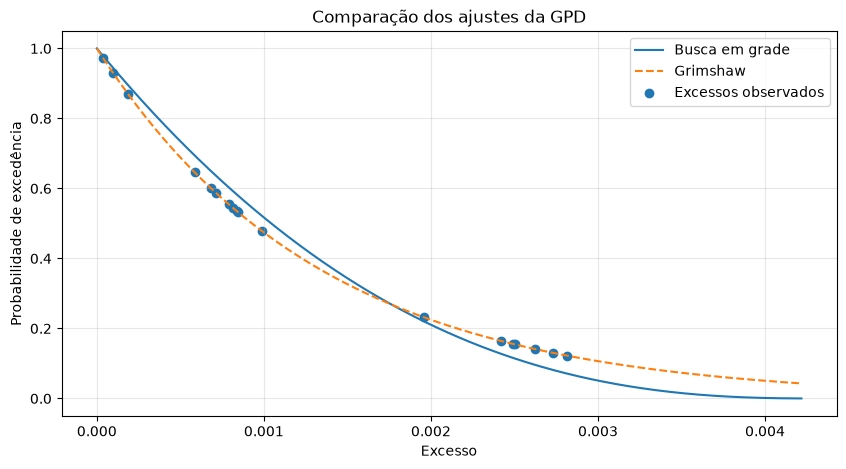

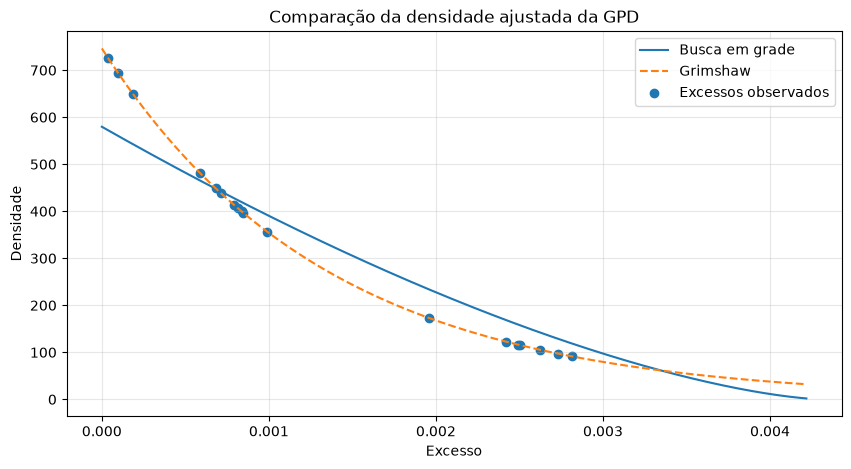

In [30]:
eixoComparacao = np.linspace(0, max(excessos) * 1.5, 500)

sobrevivenciaGrade = sobrevivenciaGPD(eixoComparacao, gammaGrade, sigmaGrade)
sobrevivenciaGrimshaw = sobrevivenciaGPD(eixoComparacao, gammaGrimshaw, sigmaGrimshaw)

densidadeGrade = densidadeGPD(eixoComparacao, gammaGrade, sigmaGrade)
densidadeGrimshaw = densidadeGPD(eixoComparacao, gammaGrimshaw, sigmaGrimshaw)

plt.figure(figsize=(10, 5))
plt.plot(eixoComparacao, sobrevivenciaGrade, label="Busca em grade")
plt.plot(eixoComparacao, sobrevivenciaGrimshaw, linestyle="--", label="Grimshaw")
plt.scatter(excessos, sobrevivenciaGPD(excessos, gammaGrimshaw, sigmaGrimshaw), label="Excessos observados")
plt.xlabel("Excesso")
plt.ylabel("Probabilidade de excedência")
plt.title("Comparação dos ajustes da GPD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(eixoComparacao, densidadeGrade, label="Busca em grade")
plt.plot(eixoComparacao, densidadeGrimshaw, linestyle="--", label="Grimshaw")
plt.scatter(excessos, densidadeGPD(excessos, gammaGrimshaw, sigmaGrimshaw), label="Excessos observados")
plt.xlabel("Excesso")
plt.ylabel("Densidade")
plt.title("Comparação da densidade ajustada da GPD")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Cálculo do limiar extremo

Os parâmetros encontrados pela busca em grade e pelo Grimshaw serão utilizados separadamente para calcular o limiar extremo. Dessa forma, poderemos observar quanto o método de estimação influencia o valor final utilizado para detectar anomalias.

O cálculo também considera o limiar intermediário, a quantidade total de observações, o número de picos e o risco de excedência configurado.

<img src="img/GPD_05.png" width="900">

In [31]:
def calcularZq(limiar, gamma, sigma, quantidadeObservacoes, quantidadePicos, risco):
    if sigma <= 0:
        raise ValueError("Sigma deve ser maior que zero.")

    if quantidadeObservacoes <= 0:
        raise ValueError("A quantidade de observações deve ser positiva.")

    if quantidadePicos <= 0:
        raise ValueError("A quantidade de picos deve ser positiva.")

    if not 0 < risco < 1:
        raise ValueError("O risco deve estar entre zero e um.")

    # Caso exponencial.
    if np.isclose(gamma, 0.0):
        return (limiar + sigma * np.log(quantidadePicos / (risco * quantidadeObservacoes)))

    razao = (risco * quantidadeObservacoes / quantidadePicos)

    return (limiar + sigma / gamma * (razao ** (-gamma) - 1))

## 5.1 Definição do risco de excedência

O risco representa a probabilidade-alvo de um valor normal ultrapassar o limiar extremo. Quanto menor esse valor, mais distante e conservador tende a ser o limiar. Quanto maior o risco, menor será o nível necessário para que uma observação seja considerada extrema.

O mesmo risco será utilizado nos dois métodos para que a única diferença entre os limiares seja causada pelos parâmetros estimados.

In [32]:
q = 0.001

print("Risco utilizado:", q)
print("Quantidade total n:", n)
print("Quantidade de picos Nt:", numeroPicos)
print("Limiar intermediário t:", limiarT)

Risco utilizado: 0.001
Quantidade total n: 900
Quantidade de picos Nt: 18
Limiar intermediário t: 0.33089106383559685


## 5.2 Limiar calculado com os parâmetros da busca em grade

Nesta etapa utilizamos os parâmetros de forma e escala encontrados pela busca em grade. O resultado será armazenado separadamente para permitir a comparação com o limiar obtido pelo Grimshaw.

In [33]:
zqGrade = calcularZq(
    limiar=limiarT,
    gamma=gammaGrade,
    sigma=sigmaGrade,
    quantidadeObservacoes=n,
    quantidadePicos=numeroPicos,
    risco=q
)

print("Gamma da grade:", gammaGrade)
print("Sigma da grade:", sigmaGrade)
print("zq da busca em grade:", zqGrade)

Gamma da grade: -0.4
Sigma da grade: 0.0017249465836975512
zq da busca em grade: 0.3339023513126967


## 5.3 Limiar calculado com os parâmetros do Grimshaw

Agora repetimos o mesmo cálculo utilizando os parâmetros estimados pelo Grimshaw. O limiar intermediário, o risco, a quantidade de observações e o número de picos permanecem iguais.

Assim, qualquer diferença no resultado será produzida exclusivamente pelas estimativas de forma e escala.

In [34]:
zqGrimshaw = calcularZq(
    limiar=limiarT,
    gamma=gammaGrimshaw,
    sigma=sigmaGrimshaw,
    quantidadeObservacoes=n,
    quantidadePicos=numeroPicos,
    risco=q
)

print("Gamma do Grimshaw:", gammaGrimshaw)
print("Sigma do Grimshaw:", sigmaGrimshaw)
print("zq do Grimshaw:", zqGrimshaw)

Gamma do Grimshaw: 0.0
Sigma do Grimshaw: 0.0013400262824344897
zq do Grimshaw: 0.33490542381729643


## 5.4 Comparação dos limiares extremos

Os dois limiares representam o mesmo risco, mas foram calculados com parâmetros obtidos por métodos diferentes. Valores próximos indicam que a busca em grade aproximou adequadamente a solução encontrada pelo Grimshaw.

Uma diferença elevada pode indicar que a grade possui baixa resolução, que o conjunto contém poucos excessos ou que o ajuste da GPD apresenta instabilidade.

In [35]:
comparacaoLimiares = pd.DataFrame({
    "metodo": [
        "Busca em grade",
        "Grimshaw"
    ],
    "gamma": [
        gammaGrade,
        gammaGrimshaw
    ],
    "sigma": [
        sigmaGrade,
        sigmaGrimshaw
    ],
    "zq": [
        zqGrade,
        zqGrimshaw
    ],
    "logVerossimilhanca": [
        logGrade,
        logGrimshaw
    ]
})

diferencaZq = (zqGrimshaw - zqGrade)
diferencaPercentualZq = (abs(diferencaZq) / max(abs(zqGrimshaw), 1e-12) * 100)

print("Diferença absoluta entre os limiares:", diferencaZq)
print("Diferença percentual:", f"{diferencaPercentualZq:.6f}%")

comparacaoLimiares

Diferença absoluta entre os limiares: 0.0010030725045997446
Diferença percentual: 0.299509%


,metodo,gamma,sigma,zq,logVerossimilhanca
0,Busca em grade,-0.4,0.001725,0.333902,102.769746
1,Grimshaw,0.0,0.001340,0.334905,101.071189


## 5.5 Visualização dos resultados

O gráfico apresenta o limiar intermediário e os dois limiares extremos. Os valores acima do limiar intermediário continuam sendo os picos usados na modelagem da cauda. Os valores que ultrapassam cada limiar extremo seriam classificados como anomalias pelo respectivo método.

Quando as linhas dos dois limiares ficam praticamente sobrepostas, os métodos produziram decisões semelhantes para a série analisada.

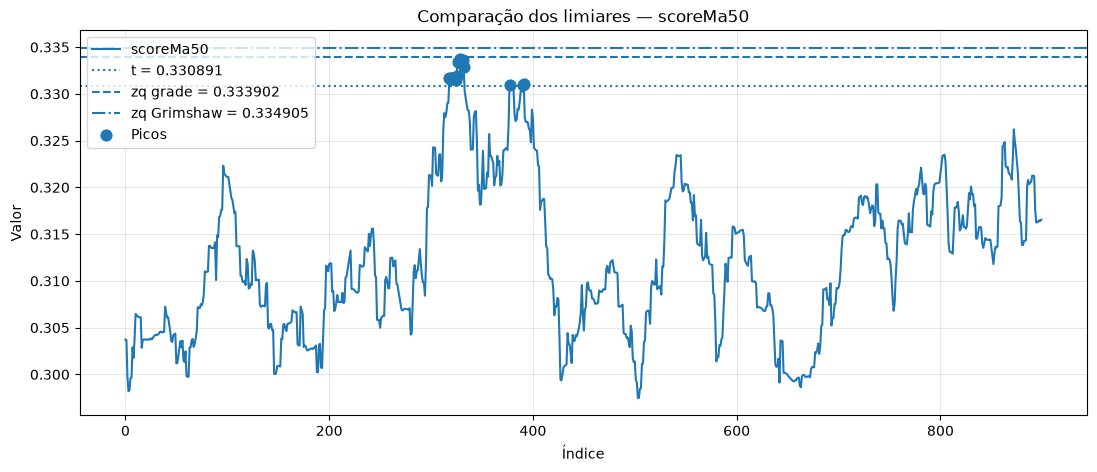

In [36]:
indices = np.arange(len(serie))

plt.figure(figsize=(13, 5))
plt.plot(indices, serie, label=nomeSerie)
plt.axhline(limiarT, linestyle=":", label=f"t = {limiarT:.6f}")
plt.axhline(zqGrade, linestyle="--", label=f"zq grade = {zqGrade:.6f}")
plt.axhline(zqGrimshaw, linestyle="-.", label=f"zq Grimshaw = {zqGrimshaw:.6f}")
plt.scatter(indices[serie > limiarT], serie[serie > limiarT], s=60, label="Picos")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title(f"Comparação dos limiares — {nomeSerie}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5.6 Comparação das classificações

Nesta última análise, cada valor será classificado separadamente pelos dois limiares. Um valor pode ser comum, pico ou anomalia. Isso permite verificar diretamente se a diferença entre os parâmetros estimados provocou alguma mudança nas decisões finais.

In [37]:
def classificarValores(valores, limiarIntermediario, limiarExtremo):
    classificacao = np.full(len(valores), "comum", dtype=object)
    classificacao[(valores > limiarIntermediario) & (valores <= limiarExtremo)] = "pico"
    classificacao[valores > limiarExtremo] = "anomalia"

    return classificacao


classificacaoGrade = classificarValores(serie, limiarT, zqGrade)
classificacaoGrimshaw = classificarValores(serie, limiarT, zqGrimshaw)

tabelaClassificacoes = pd.DataFrame({
    "indice": np.arange(len(serie)),
    "valor": serie,
    "buscaEmGrade": classificacaoGrade,
    "grimshaw": classificacaoGrimshaw
})

decisoesDiferentes = tabelaClassificacoes[
    tabelaClassificacoes["buscaEmGrade"]
    != tabelaClassificacoes["grimshaw"]
]

print("Quantidade de decisões diferentes:", len(decisoesDiferentes))
tabelaClassificacoes

Quantidade de decisões diferentes: 0


,indice,valor,buscaEmGrade,grimshaw
0,0,0.303731,comum,comum
1,1,0.303673,comum,comum
2,2,0.299726,comum,comum
3,3,0.298208,comum,comum
4,4,0.298279,comum,comum
...,...,...,...,...
895,895,0.316256,comum,comum
896,896,0.316347,comum,comum
897,897,0.316479,comum,comum
898,898,0.316411,comum,comum
